<a href="https://colab.research.google.com/github/harshitapaila369-collab/harshu/blob/main/internship2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Decision Tree Accuracy:
0.7623529411764706

Random Forest Accuracy:
0.8202941176470588


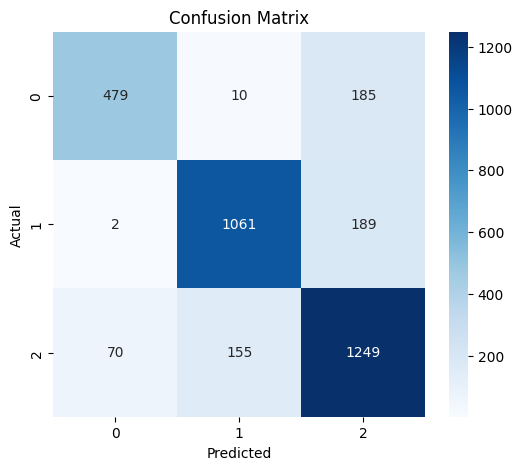


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       674
           1       0.87      0.85      0.86      1252
           2       0.77      0.85      0.81      1474

    accuracy                           0.82      3400
   macro avg       0.83      0.80      0.81      3400
weighted avg       0.82      0.82      0.82      3400


ROC Curve not generated: Target variable has more than two classes, or is not binary.

Skipping Linear Regression: Target variable is now categorical, not continuous.

Feature Importance:
              Feature  Importance
7       median_income    0.276053
0           longitude    0.180297
1            latitude    0.169457
5          population    0.085269
3         total_rooms    0.080111
4      total_bedrooms    0.070252
2  housing_median_age    0.069687
6          households    0.068874


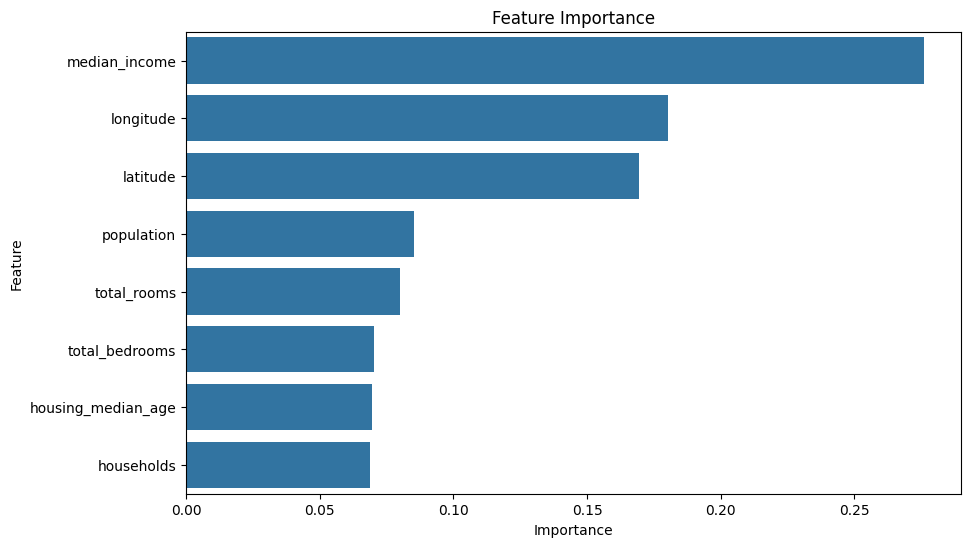


Predictions Saved Successfully!

Predictive Modeling Completed Successfully!


In [2]:
# =========================================================
# Predictive Modeling Using Machine Learning
# =========================================================

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# =========================================================
# Step 1: Load Dataset
# =========================================================

# Replace 'dataset.csv' with your dataset file
# Using 'california_housing_train.csv' as a placeholder since 'dataset.csv' was not found.
data = pd.read_csv("/content/sample_data/california_housing_train.csv")

print("First 5 Rows:")
print(data.head())

# =========================================================
# Step 2: Handle Missing Values
# =========================================================

# Fill numeric missing values with mean, ensuring assignment is explicit
numeric_columns = data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if data[column].isnull().any(): # Only attempt to fill if there are NaNs
        data[column] = data[column].fillna(data[column].mean())

# Fill categorical missing values with mode
categorical_columns = data.select_dtypes(include='object').columns

for column in categorical_columns:
    if data[column].isnull().any(): # Only attempt to fill if there are NaNs
        data[column] = data[column].fillna(data[column].mode()[0])

# =========================================================
# Step 3: Encode Categorical Data and Prepare Target
# =========================================================

# Encode any existing categorical columns (though california_housing_train.csv has none)
encoder = LabelEncoder()
for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])

# Discretize the continuous target (median_house_value) into categories
# This is necessary as the chosen models (DecisionTreeClassifier, RandomForestClassifier)
# are for classification, expecting discrete labels for y.
data['median_house_value_category'] = pd.cut(data['median_house_value'],
                                             bins=[0, 150000, 300000, np.inf],
                                             labels=['Low', 'Medium', 'High'],
                                             right=False) # Use 0 <= value < 150000 etc.

# Encode the new categorical target variable for model training
# This encoder will be specific to the 'median_house_value_category' column
class_encoder = LabelEncoder()
data['median_house_value_category_encoded'] = class_encoder.fit_transform(data['median_house_value_category'])

# =========================================================
# Step 4: Select Features and Target
# =========================================================

# Features (X): all columns except the original median_house_value and the intermediate category columns
X = data.drop(columns=['median_house_value', 'median_house_value_category', 'median_house_value_category_encoded'])
# Target (y): the newly encoded categorical house value
y = data['median_house_value_category_encoded']

# =========================================================
# Step 5: Split Dataset into Train and Test
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Step 6: Apply Decision Tree Classifier
# =========================================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("\nDecision Tree Accuracy:")
print(dt_accuracy)

# =========================================================
# Step 7: Apply Random Forest Classifier
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)

# =========================================================
# Step 8: Confusion Matrix
# =========================================================

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# Step 9: Classification Report
# =========================================================

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# =========================================================
# Step 10: ROC Curve
# =========================================================

# Works only for binary classification
# The target 'median_house_value_category' now has 3 classes, so ROC curve for binary
# classification will not work directly. We'll skip this if not binary.

if len(np.unique(y)) == 2:

    y_prob = rf_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")
    plt.legend()

    plt.show()
else:
    print("\nROC Curve not generated: Target variable has more than two classes, or is not binary.")

# =========================================================
# Step 11: Linear Regression (Optional)
# =========================================================

# Use only if target variable is continuous
# This block is now inappropriate as 'y' is categorical. Uncomment and adapt
# if you switch to a regression problem.
# if y.dtype in ['int64', 'float64']:

#     lr_model = LinearRegression()

#     lr_model.fit(X_train, y_train)

#     lr_predictions = lr_model.predict(X_test)

#     print("\nLinear Regression Model Trained Successfully!")

print("\nSkipping Linear Regression: Target variable is now categorical, not continuous.")

# =========================================================
# Step 12: Feature Importance
# =========================================================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

# =========================================================
# Step 13: Save Model Predictions
# =========================================================

results = pd.DataFrame({
    'Actual': class_encoder.inverse_transform(y_test),
    'Predicted': class_encoder.inverse_transform(rf_predictions)
})

results.to_csv("model_predictions.csv", index=False)

print("\nPredictions Saved Successfully!")

# =========================================================
# Project Completed
# =========================================================

print("\nPredictive Modeling Completed Successfully!")

### Analyzing the Target Variable Distribution

The very low accuracy (around 2%) suggests that the classification models are not performing well. A common reason for this when dealing with a discretized continuous variable is highly imbalanced classes. Let's check the distribution of the `median_house_value_category` to see if there's a significant skew in the number of samples per category. This can make it very difficult for a classifier to learn patterns for the minority classes.


Distribution of Median House Value Categories:
median_house_value_category
Medium    7568
Low       6217
High      3215
Name: count, dtype: int64


/tmp/ipykernel_11608/2963336259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='median_house_value_category', data=data, palette='viridis')


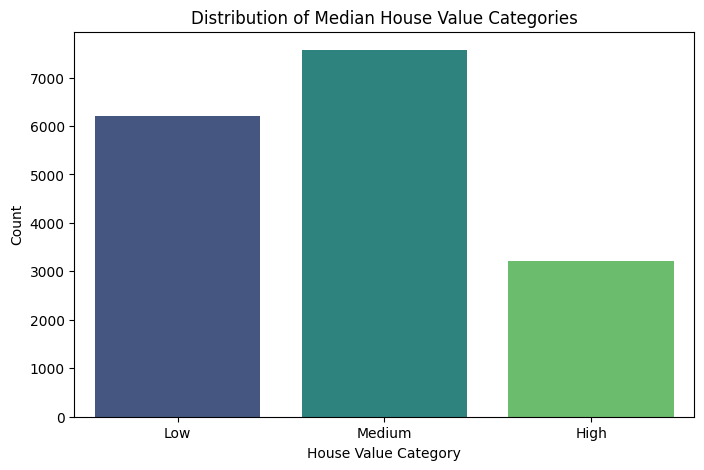

In [3]:
# Check distribution of the new target variable
print("\nDistribution of Median House Value Categories:")
print(data['median_house_value_category'].value_counts())

# Optional: Visualize the distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='median_house_value_category', data=data, palette='viridis')
plt.title('Distribution of Median House Value Categories')
plt.xlabel('House Value Category')
plt.ylabel('Count')
plt.show()